<a href="https://colab.research.google.com/github/ENRIQUESPECTER/Mineria-de-Datos/blob/main/K_Means_Ejercicios.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import pandas as pd

Ejercicio 1: Agrupamiento de clientes según comportamiento de compra
Objetivo: Aplicar K-Means para identificar tipos de clientes según sus hábitos de compra.

In [42]:
# 1. CREAR EL DATAFRAME
data = {
    "Compras_Mes": [1, 2, 1.5, 10, 12, 11, 4, 5, 6],
    "Gasto_Mensual": [2, 3, 2.5, 9, 11, 10, 5, 6, 7]
}
df = pd.DataFrame(data)
df

,Compras_Mes,Gasto_Mensual
0,1.0,2.0
1,2.0,3.0
2,1.5,2.5
3,10.0,9.0
4,12.0,11.0
5,11.0,10.0
6,4.0,5.0
7,5.0,6.0
8,6.0,7.0


<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

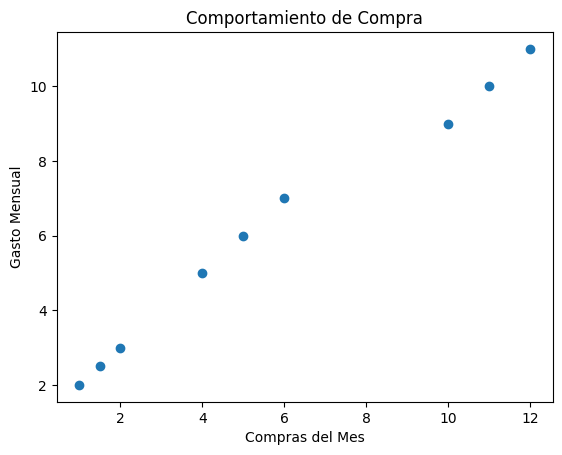

In [43]:
# 2. CREAR LA GRAFICA DEL DATAFRAME
plt.scatter(df['Compras_Mes'], df['Gasto_Mensual'])
plt.xlabel("Compras del Mes")
plt.ylabel("Gasto Mensual")
plt.title("Comportamiento de Compra")
plt

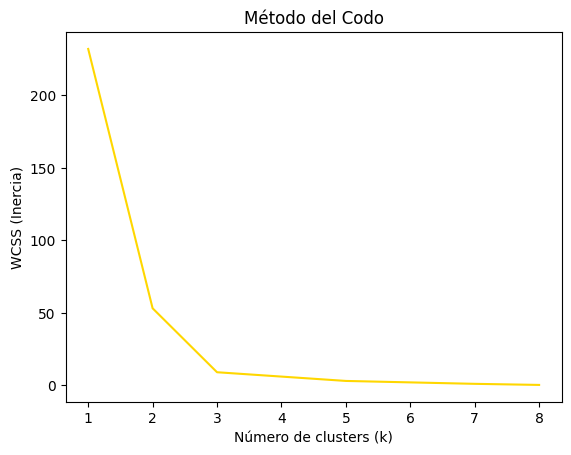

In [44]:
# 3. APLICAR Y GRAFICAR EL METODO DEL CODO
wcss = []
for i in range(1, 9):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(df)
    wcss.append(kmeans.inertia_)

# Grafica método del codo
plt.plot(range(1, 9), wcss, c='gold')
plt.title('Método del Codo')
plt.xlabel('Número de clusters (k)')
plt.ylabel('WCSS (Inercia)')
plt.show()

In [45]:
# 4. APLICAMOS K-MEANS CON K = 3
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(df)
df

,Compras_Mes,Gasto_Mensual,Cluster
0,1.0,2.0,1
1,2.0,3.0,1
2,1.5,2.5,1
3,10.0,9.0,2
4,12.0,11.0,2
5,11.0,10.0,2
6,4.0,5.0,0
7,5.0,6.0,0
8,6.0,7.0,0


In [46]:
# 5. MOSTRAR LOS CENTROIDES
centroides = kmeans.cluster_centers_
centroides

array([[ 5. ,  6. ],
       [ 1.5,  2.5],
       [11. , 10. ]])

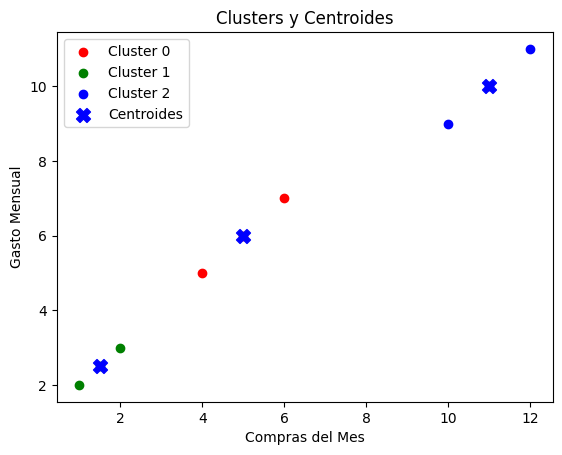

In [47]:
# 6. GRAFICAR LOS CLUSTERES CON LOS CENTROIDES

colores = ['red', 'green', 'blue']

for i in range(3):
    puntos = df[df['Cluster'] == i]
    plt.scatter(puntos['Compras_Mes'], puntos['Gasto_Mensual'], c=colores[i], label=f'Cluster {i}')

plt.scatter(centroides[:, 0], centroides[:, 1], c=colores[i], marker='X', s=100, label='Centroides')
plt.xlabel("Compras del Mes")
plt.ylabel("Gasto Mensual")
plt.title("Clusters y Centroides")
plt.legend()
plt.show()

Ejercicio 2: Agrupamiento de personas según salud física
Objetivo: Identificar grupos de personas según su condición física.

In [48]:
data = {
    "Ejercicio": [ 0.5, 1, 1.5, 6, 7, 8, 2, 3, 4],
    "Condicion_Fisica": [2, 3, 2.5, 8, 9, 10, 4, 5, 6]
}
df = pd.DataFrame(data)
df

,Ejercicio,Condicion_Fisica
0,0.5,2.0
1,1.0,3.0
2,1.5,2.5
3,6.0,8.0
4,7.0,9.0
5,8.0,10.0
6,2.0,4.0
7,3.0,5.0
8,4.0,6.0


<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

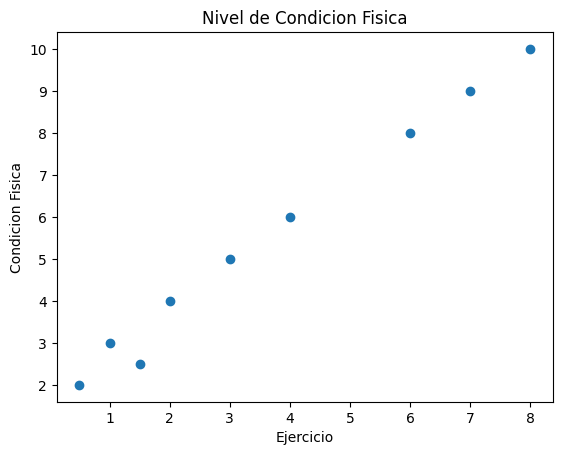

In [49]:
plt.scatter(df['Ejercicio'], df['Condicion_Fisica'])
plt.xlabel("Ejercicio")
plt.ylabel("Condicion Fisica")
plt.title("Nivel de Condicion Fisica")
plt

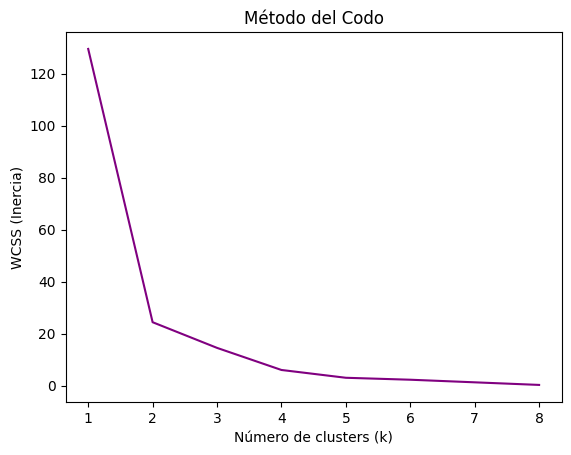

In [50]:
wcss = []

for i in range(1,9):
  kmeans = KMeans(n_clusters=i, random_state=42)
  kmeans.fit(df)
  wcss.append(kmeans.inertia_)

plt.plot(range(1,9), wcss, c='purple')
plt.title('Método del Codo')
plt.xlabel('Número de clusters (k)')
plt.ylabel('WCSS (Inercia)')
plt.show()

In [51]:
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(df)
df

,Ejercicio,Condicion_Fisica,Cluster
0,0.5,2.0,1
1,1.0,3.0,1
2,1.5,2.5,1
3,6.0,8.0,0
4,7.0,9.0,2
5,8.0,10.0,2
6,2.0,4.0,1
7,3.0,5.0,1
8,4.0,6.0,0


In [52]:
centroides = kmeans.cluster_centers_
centroides

array([[5. , 7. ],
       [1.6, 3.3],
       [7.5, 9.5]])

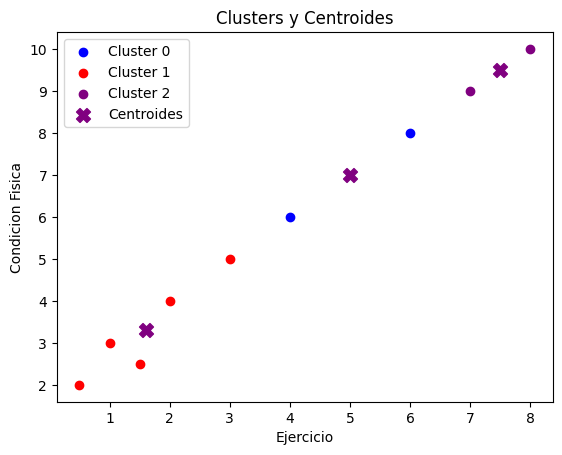

In [53]:
colores = ['blue','red','purple']

for i in range(3):
  cluster = df[df['Cluster'] == i]
  plt.scatter(cluster['Ejercicio'], cluster['Condicion_Fisica'], c=colores[i], label=f'Cluster {i}')

plt.scatter(centroides[:, 0], centroides[:, 1], c=colores[i], marker='X', s=100, label='Centroides')
plt.xlabel("Ejercicio")
plt.ylabel("Condicion Fisica")
plt.title("Clusters y Centroides")
plt.legend()
plt.show()

Ejercicio 3: Agrupamiento de productos según ventas
Objetivo: Clasificar productos según su desempeño en ventas.


In [54]:
data = {
    "Ventas": [2, 3, 2.5, 15, 18, 20, 5, 6, 7],
    "Ingresos": [3, 4, 3.5, 9, 10, 10, 5, 6, 7]
}
df = pd.DataFrame(data)
df

,Ventas,Ingresos
0,2.0,3.0
1,3.0,4.0
2,2.5,3.5
3,15.0,9.0
4,18.0,10.0
5,20.0,10.0
6,5.0,5.0
7,6.0,6.0
8,7.0,7.0


<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

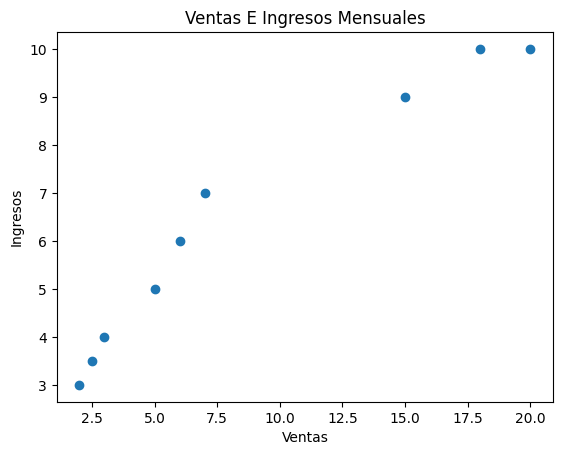

In [55]:
plt.scatter(df['Ventas'], df['Ingresos'])
plt.xlabel("Ventas")
plt.ylabel("Ingresos")
plt.title("Ventas E Ingresos Mensuales")
plt

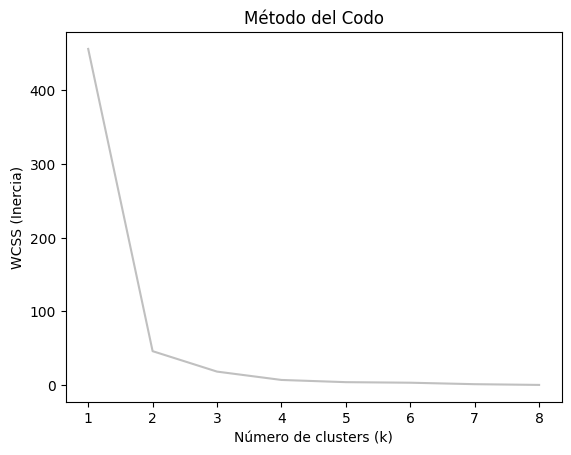

In [69]:
wcss = []

for i in range(1,9):
  kmeans = KMeans(n_clusters=i, random_state=42)
  kmeans.fit(df)
  wcss.append(kmeans.inertia_)

plt.plot(range(1,9), wcss, c='silver')
plt.title('Método del Codo')
plt.xlabel('Número de clusters (k)')
plt.ylabel('WCSS (Inercia)')
plt.show()

In [64]:
kmeans = KMeans(n_clusters=2, random_state=42)
df['Cluster'] = kmeans.fit_predict(df)
df

,Ventas,Ingresos,Cluster
0,2.0,3.0,1
1,3.0,4.0,1
2,2.5,3.5,1
3,15.0,9.0,0
4,18.0,10.0,0
5,20.0,10.0,0
6,5.0,5.0,1
7,6.0,6.0,1
8,7.0,7.0,1


In [65]:
centroides = kmeans.cluster_centers_
centroides

array([[17.66666667,  9.66666667,  0.        ],
       [ 4.25      ,  4.75      ,  1.        ]])

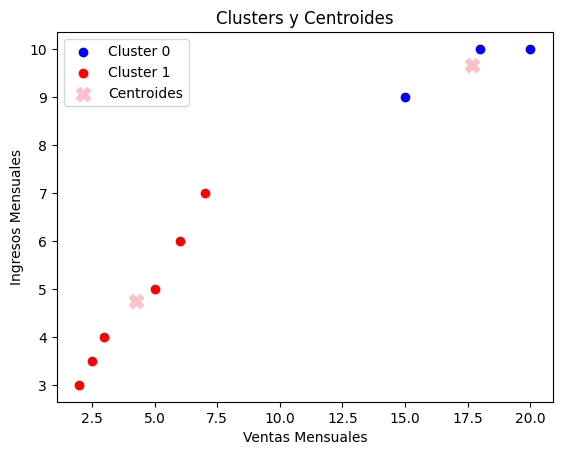

In [70]:
colores = ['blue','red']

for i in range(2):
  cluster = df[df['Cluster'] == i]
  plt.scatter(cluster['Ventas'], cluster['Ingresos'], c=colores[i], label=f'Cluster {i}')

plt.scatter(centroides[:, 0], centroides[:, 1], c='pink', marker='X', s=100, label='Centroides')
plt.xlabel('Ventas Mensuales')
plt.ylabel('Ingresos Mensuales')
plt.title('Clusters y Centroides')
plt.legend()
plt.show()